#  Notebook Overview: Advanced SAM-FiLM-Net Crack Segmentation

This notebook implements the production-ready Advanced SAM-FiLM-Net pipeline for high-fidelity crack segmentation.

###  Execution Steps:
1. **Dependencies:** Sets up the environment with CLIP, SAM, and numerical processing libraries.
2. **Exploratory Data Analysis (EDA):** Visualizes 5 random samples from the dataset to verify image/mask alignment.
3. **Resilient Data Pipeline:** Loads the `cracks_dataset_v2` with robust error checking for missing files.
4. **Architecture Construction:** Implements the `AdvancedSAMFiLM` system:
   - Resizes SAM ViT-B positional embeddings for custom resolutions.
   - Deeply integrates FiLM conditioning for dynamic text prompting.
   - Uses a Dilated Spatial Decoder and a Laplacian Edge-Aware Head for crisp boundary detection.
5. **Weighted Loss Logic:** Prevents background collapse using a weighted BCE + Dice + Edge loss strategy.
6. **Global Cache Training:** Pre-computes prompt tokens via CLIP for maximum training throughput.
7. **Comprehensive Evaluation:** Runs an independent test set scorecard tracking IoU (Foreground), mIoU (Mean), Precision, Recall, and F1.
8. **Visual Prediction Review:** Plots 10 high-resolution samples comparing Original Images, Ground Truths, and Model Predictions side-by-side.
9. **failure_case_analysis**
10. **Complexity_analysis**

In [2]:
import os, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import clip
from segment_anything import sam_model_registry

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

class Config:
    DATASET_DIR = "cracks_dataset_v2" 
    PROMPTS = ["segment crack", "segment wall crack"]
    IMAGE_SIZE = 224
    BATCH_SIZE = 4
    NUM_EPOCHS = 30
    LEARNING_RATE = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(f"Using Accelerated Device: {cfg.DEVICE}")


/home/nagendra/anaconda3/envs/crk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Accelerated Device: cuda


Plotting 5 Random Images from Dataset for Analysis...


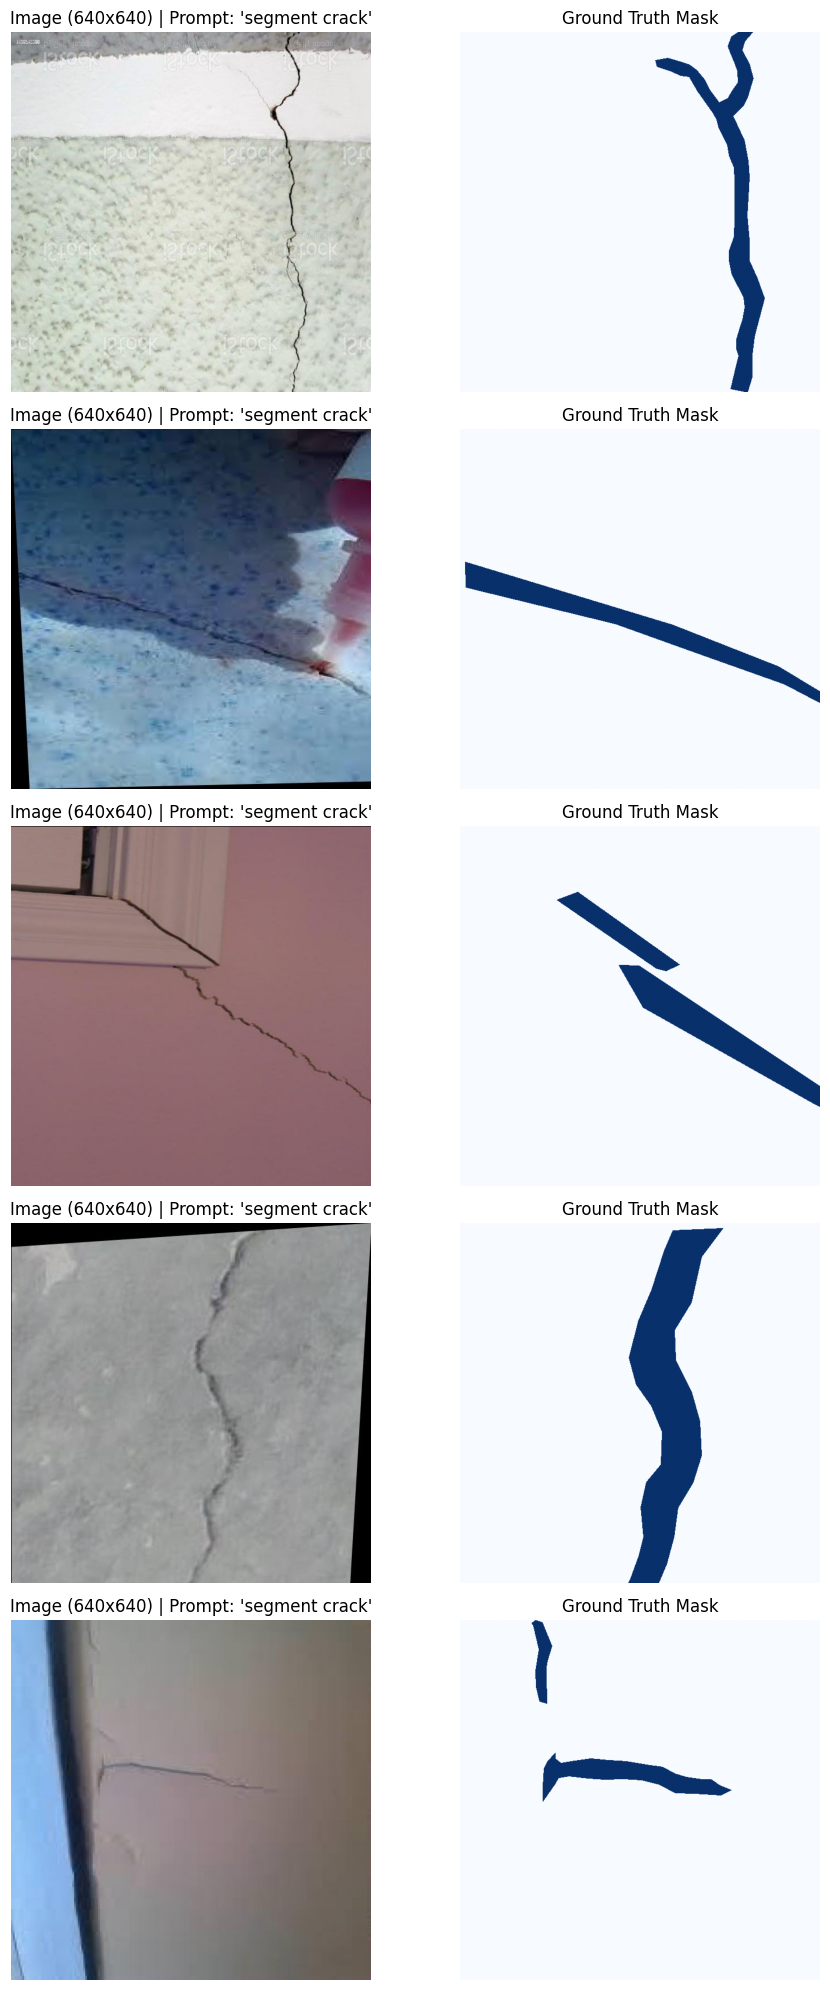

In [12]:
# 1. Exploratory Data Analysis (EDA)
print("Plotting 5 Random Images from Dataset for Analysis...")
with open(os.path.join(cfg.DATASET_DIR, "metadata.json"), "r") as f:
    metadata = json.load(f)["images"]

train_images = [m for m in metadata if m["split"] == "train"]
samples = random.sample(train_images, 5)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
for i, sample in enumerate(samples):
    img_path = os.path.join(cfg.DATASET_DIR, "train", "images", sample["image_file"])
    mask_path = os.path.join(cfg.DATASET_DIR, "train", "masks", sample["mask_file"])
    
    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")
    
    prompt = random.choice(cfg.PROMPTS)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Image ({img.width}x{img.height}) | Prompt: '{prompt}'")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="Blues")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [3]:
# 2. Resilient Dataset Pipeline
class CrackDataset(Dataset):
    def __init__(self, split, dataset_dir, prompts, image_size=224):
        self.split, self.prompts, self.image_size = split, prompts, image_size
        self.dataset_dir = dataset_dir
        with open(os.path.join(dataset_dir, "metadata.json"), "r") as f:
            metadata = json.load(f)
        
        self.samples = []
        for m in metadata["images"]:
            if m["split"] == split:
                if os.path.exists(os.path.join(dataset_dir, split, "masks", m["mask_file"])):
                    self.samples.append(m)
        print(f"{split.upper()}: Loaded {len(self.samples)} valid items.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(os.path.join(self.dataset_dir, self.split, "images", sample["image_file"])).convert("RGB")
        mask = Image.open(os.path.join(self.dataset_dir, self.split, "masks", sample["mask_file"])).convert("L")
        img = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)
        
        return transforms.ToTensor()(img), torch.from_numpy(np.array(mask)).float() / 255.0, random.choice(self.prompts)

train_ds = CrackDataset("train", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
val_ds = CrackDataset("val", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)
test_ds = CrackDataset("test", cfg.DATASET_DIR, cfg.PROMPTS, cfg.IMAGE_SIZE)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=4)


TRAIN: Loaded 3756 valid items.
VAL: Loaded 805 valid items.
TEST: Loaded 806 valid items.


In [4]:
# 3. Advanced Modules (FiLM, Dilated Decoder, Edge Head)
class FiLMGenerator(nn.Module):
    def __init__(self, text_dim=512, feat_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(text_dim, 256), nn.ReLU(inplace=True),
            nn.Linear(256, 256), nn.ReLU(inplace=True),
            nn.Linear(256, feat_dim * 2) 
        )
        nn.init.zeros_(self.mlp[-1].weight)
        nn.init.zeros_(self.mlp[-1].bias)
        with torch.no_grad(): self.mlp[-1].bias[:feat_dim] = 1.0

    def forward(self, text_emb):
        out = self.mlp(text_emb)
        return out[:, :256], out[:, 256:]

    def modulate(self, features, gamma, beta):
        return gamma[:, :, None, None] * features + beta[:, :, None, None]

class DilatedDecoder(nn.Module):
    def __init__(self, in_dim=256, out_dim=128):
        super().__init__()
        b_dim = in_dim // 4
        self.global_ctx = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(in_dim, b_dim, 1), nn.ReLU(inplace=True))
        self.d1 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=1, dilation=1, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d3 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=3, dilation=3, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d6 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=6, dilation=6, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.d12 = nn.Sequential(nn.Conv2d(in_dim, b_dim, 3, padding=12, dilation=12, bias=False), nn.GroupNorm(8, b_dim), nn.ReLU(inplace=True))
        self.project = nn.Sequential(nn.Conv2d(b_dim * 5, out_dim, 1), nn.GroupNorm(8, out_dim), nn.ReLU(inplace=True), nn.Dropout2d(0.1))

    def forward(self, x):
        ctx = self.global_ctx(x).expand(-1, -1, x.shape[2], x.shape[3])
        return self.project(torch.cat([ctx, self.d1(x), self.d3(x), self.d6(x), self.d12(x)], dim=1))

class EdgeAwareHead(nn.Module):
    def __init__(self, feat_dim=16):
        super().__init__()
        laplacian = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).repeat(1, 1, 1, 1)
        self.register_buffer("laplacian_kernel", laplacian)
        
        self.edge_encoder = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(inplace=True))
        self.channel_attn = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(feat_dim + 16, 16), nn.ReLU(inplace=True), nn.Linear(16, feat_dim), nn.Sigmoid())
        
        self.refine = nn.Sequential(
            nn.Conv2d(feat_dim + 16, feat_dim, 3, padding=1), nn.GroupNorm(4, feat_dim), nn.ReLU(inplace=True),
            nn.Conv2d(feat_dim, feat_dim // 2, 3, padding=1), nn.GroupNorm(4, feat_dim // 2), nn.ReLU(inplace=True)
        )
        self.head = nn.Conv2d(feat_dim // 2, 1, 1)

    def extract_edges(self, image):
        gray = 0.299 * image[:, 0:1] + 0.587 * image[:, 1:2] + 0.114 * image[:, 2:3]
        edges = F.conv2d(gray, self.laplacian_kernel, padding=1).abs()
        B = edges.shape[0]
        max_vals = edges.view(B, -1).max(dim=1)[0].view(B, 1, 1, 1).clamp(min=1e-6)
        return edges / max_vals

    def forward(self, feats, image):
        image_resized = F.interpolate(image, size=(feats.shape[2], feats.shape[3]), mode="bilinear", align_corners=False)
        edge_map = self.extract_edges(image_resized)
        edge_feats = self.edge_encoder(edge_map)
        
        attn = self.channel_attn(torch.cat([feats, edge_feats], dim=1))[:, :, None, None]
        gated = feats * attn
        
        refined = self.refine(torch.cat([gated, edge_feats], dim=1))
        return self.head(refined)


In [5]:
# 4. The Final Advanced SAM Model
class AdvancedSAMFiLM(nn.Module):
    def __init__(self, image_size=224):
        super().__init__()
        self.sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
        
        # Resize internal pos embeddings to match 224 output grid (14x14)
        grid_size = image_size // 16 
        old_pos = self.sam.image_encoder.pos_embed 
        new_pos = F.interpolate(old_pos.permute(0, 3, 1, 2), size=(grid_size, grid_size), mode='bicubic', align_corners=False)
        self.sam.image_encoder.pos_embed = nn.Parameter(new_pos.permute(0, 2, 3, 1)) 
        for param in self.sam.image_encoder.parameters(): param.requires_grad = False
        
        # Novel Modules
        self.film = FiLMGenerator(text_dim=512, feat_dim=256)
        self.dilated = DilatedDecoder(in_dim=256, out_dim=128)
        
        # Upsampling block to get from 14x14 to 224x224 before Edge Head
        self.upsampler = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 16, 4, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
        )
        self.edge_head = EdgeAwareHead(feat_dim=16)
        
    def forward(self, img, text_emb):
        with torch.no_grad(): img_features = self.sam.image_encoder(img)
        gamma, beta = self.film(text_emb)
        modulated = self.film.modulate(img_features, gamma, beta)
        
        decoded = self.dilated(modulated)
        upsampled = self.upsampler(decoded)
        logits = self.edge_head(upsampled, img)
        return logits.squeeze(1)

print("Booting up Foundation Models...")
clip_model, _ = clip.load("ViT-B/32", cfg.DEVICE)
clip_model = clip_model.float().eval()

model = AdvancedSAMFiLM().to(cfg.DEVICE)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.LEARNING_RATE)
print(f"Total Trainable Base Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Booting up Foundation Models...


/home/nagendra/anaconda3/envs/crk/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Total Trainable Base Parameters: 5,227,025


In [16]:
# 5. Advanced Segmentation Loss (Class Imbalance Patched)
class SegmentationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        lap = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        self.register_buffer("lap_kernel", lap)

    def forward(self, logits, targets):
        if logits.dim() == 3: logits = logits.unsqueeze(1)
        if targets.dim() == 3: targets = targets.unsqueeze(1)
        
        # BCE with Massive Positive Weighting (Class Imbalance Fix)
        # Prevents the model from collapsing to "all 0s" to achieve an easy low BCE score
        pos_weight = torch.tensor([15.0], device=logits.device)
        l_bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
        
        # DICE (Prioritizes Foreground Mathematical Overlap)
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).flatten(1).sum(dim=1)
        union = probs.flatten(1).sum(dim=1) + targets.flatten(1).sum(dim=1)
        l_dice = (1.0 - (2.0 * intersection + 1e-5) / (union + 1e-5)).mean()
        
        # EDGE (Penalize missing mathematically-defined physical boundaries)
        gt_edges = F.conv2d(targets, self.lap_kernel, padding=1).abs()
        gt_edges = (gt_edges > 0.1).float()
        
        edge_bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        l_edge = (edge_bce * (1.0 + 5.0 * gt_edges)).mean()
        
        # 2.0x weight multiplier pushes the model to physically care about overlapping the crack
        return l_bce + 2.0 * l_dice + 0.2 * l_edge

criterion = SegmentationLoss().to(cfg.DEVICE)


In [17]:
# 6. Ultra-Fast Advanced Training Loop
print("Global text embedding cache loading...")
with torch.no_grad():
    text_cache = {p: clip_model.encode_text(clip.tokenize(p).to(cfg.DEVICE)).detach() for p in cfg.PROMPTS}

best_miou = 0

for epoch in range(cfg.NUM_EPOCHS):
    model.train()
    train_loss = 0
    t_inter, t_psum, t_tsum = 0.0, 0.0, 0.0
    t_inter_bg, t_psum_bg, t_tsum_bg = 0.0, 0.0, 0.0
    
    for images, masks, prompts in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
        images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        
        optimizer.zero_grad()
        logits = model(images, text_emb)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        with torch.no_grad():
            p = (torch.sigmoid(logits) > 0.5).float().flatten(1)
            t = (masks > 0.5).float().flatten(1)
            p_bg, t_bg = 1.0 - p, 1.0 - t
            
            t_inter += (p * t).sum().item(); t_psum += p.sum().item(); t_tsum += t.sum().item()
            t_inter_bg += (p_bg * t_bg).sum().item(); t_psum_bg += p_bg.sum().item(); t_tsum_bg += t_bg.sum().item()
            
    t_loss = train_loss / len(train_loader)
    
    t_iou_fg = (t_inter + 1e-8) / (t_psum + t_tsum - t_inter + 1e-8)
    t_iou_bg = (t_inter_bg + 1e-8) / (t_psum_bg + t_tsum_bg - t_inter_bg + 1e-8)
    t_miou = (t_iou_fg + t_iou_bg) / 2.0
    
    t_prec = (t_inter + 1e-8) / (t_psum + 1e-8)
    t_rec  = (t_inter + 1e-8) / (t_tsum + 1e-8)
    t_f1   = 2 * t_prec * t_rec / (t_prec + t_rec + 1e-8)
    t_dice = (2 * t_inter + 1e-8) / (t_psum + t_tsum + 1e-8)
    
    model.eval()
    val_loss = 0
    v_inter, v_psum, v_tsum = 0.0, 0.0, 0.0
    v_inter_bg, v_psum_bg, v_tsum_bg = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for images, masks, prompts in tqdm(val_loader, desc=f"Epoch {epoch+1} Val  "):
            images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
            text_emb = torch.stack([text_cache[p][0] for p in prompts])
            logits = model(images, text_emb)
            val_loss += criterion(logits, masks).item()
            
            p = (torch.sigmoid(logits) > 0.5).float().flatten(1)
            t = (masks > 0.5).float().flatten(1)
            p_bg, t_bg = 1.0 - p, 1.0 - t
            
            v_inter += (p * t).sum().item(); v_psum += p.sum().item(); v_tsum += t.sum().item()
            v_inter_bg += (p_bg * t_bg).sum().item(); v_psum_bg += p_bg.sum().item(); v_tsum_bg += t_bg.sum().item()
            
    v_loss = val_loss / len(val_loader)
    v_iou_fg = (v_inter + 1e-8) / (v_psum + v_tsum - v_inter + 1e-8)
    v_iou_bg = (v_inter_bg + 1e-8) / (v_psum_bg + v_tsum_bg - v_inter_bg + 1e-8)
    v_miou = (v_iou_fg + v_iou_bg) / 2.0
    
    v_prec = (v_inter + 1e-8) / (v_psum + 1e-8)
    v_rec  = (v_inter + 1e-8) / (v_tsum + 1e-8)
    v_f1   = 2 * v_prec * v_rec / (v_prec + v_rec + 1e-8)
    v_dice = (2 * v_inter + 1e-8) / (v_psum + v_tsum + 1e-8)
    
    print(f"\n--- Epoch {epoch+1:02d}/{cfg.NUM_EPOCHS} ---")
    print(f"TRAIN | Loss: {t_loss:.4f} | IoU: {t_iou_fg:.4f} | mIoU: {t_miou:.4f} | Prec: {t_prec:.4f} | Rec: {t_rec:.4f} | F1: {t_f1:.4f} ")
    print(f"VAL   | Loss: {v_loss:.4f} | IoU: {v_iou_fg:.4f} | mIoU: {v_miou:.4f} | Prec: {v_prec:.4f} | Rec: {v_rec:.4f} | F1: {v_f1:.4f} ")
    print("-" * 100)
    
    if v_iou_fg > best_miou:
        best_miou = v_iou_fg
        torch.save(model.state_dict(), "best_sam_advanced.pth")


Global text embedding cache loading...


Epoch 1 Val  : 100%|██████████████████████████| 202/202 [00:10<00:00, 19.31it/s]



--- Epoch 01/30 ---
TRAIN | Loss: 2.5106 | IoU: 0.2776 | mIoU: 0.5880 | Prec: 0.2950 | Rec: 0.8242 | F1: 0.4345 
VAL   | Loss: 2.3299 | IoU: 0.2900 | mIoU: 0.5930 | Prec: 0.3006 | Rec: 0.8908 | F1: 0.4496 
----------------------------------------------------------------------------------------------------


Epoch 2 Val  : 100%|██████████████████████████| 202/202 [00:08<00:00, 23.87it/s]



--- Epoch 02/30 ---
TRAIN | Loss: 2.2044 | IoU: 0.3297 | mIoU: 0.6233 | Prec: 0.3482 | Rec: 0.8613 | F1: 0.4959 
VAL   | Loss: 2.0944 | IoU: 0.3260 | mIoU: 0.6202 | Prec: 0.3426 | Rec: 0.8705 | F1: 0.4917 
----------------------------------------------------------------------------------------------------


...


--- Epoch 28/30 ---
TRAIN | Loss: 0.7907 | IoU: 0.6627 | mIoU: 0.8201 | Prec: 0.6953 | Rec: 0.9340 | F1: 0.7972 
VAL   | Loss: 2.0460 | IoU: 0.4963 | mIoU: 0.7321 | Prec: 0.6555 | Rec: 0.6714 | F1: 0.6634 
----------------------------------------------------------------------------------------------------


Epoch 29 Val  : 100%|█████████████████████████| 202/202 [00:07<00:00, 26.27it/s]



--- Epoch 29/30 ---
TRAIN | Loss: 0.7603 | IoU: 0.6764 | mIoU: 0.8276 | Prec: 0.7088 | Rec: 0.9368 | F1: 0.8070 
VAL   | Loss: 1.7554 | IoU: 0.4925 | mIoU: 0.7280 | Prec: 0.5915 | Rec: 0.7462 | F1: 0.6599 
----------------------------------------------------------------------------------------------------


Epoch 30 Val  : 100%|█████████████████████████| 202/202 [00:07<00:00, 27.93it/s]



--- Epoch 30/30 ---
TRAIN | Loss: 0.7587 | IoU: 0.6753 | mIoU: 0.8269 | Prec: 0.7074 | Rec: 0.9371 | F1: 0.8062 
VAL   | Loss: 1.7192 | IoU: 0.4944 | mIoU: 0.7282 | Prec: 0.5721 | Rec: 0.7845 | F1: 0.6617 
----------------------------------------------------------------------------------------------------


In [22]:
# 7. Final Independent Testing
print("\nLoading Best Model Checkpoint for Final Test Evaluation...")
model.load_state_dict(torch.load("best_sam_advanced.pth"))
model.eval()

t_loss = 0
v_inter, v_psum, v_tsum = 0.0, 0.0, 0.0
v_inter_bg, v_psum_bg, v_tsum_bg = 0.0, 0.0, 0.0

with torch.no_grad():
    for images, masks, prompts in tqdm(test_loader, desc="Test Set Evaluation"):
        images, masks = images.to(cfg.DEVICE, non_blocking=True), masks.to(cfg.DEVICE, non_blocking=True)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        logits = model(images, text_emb)
        t_loss += criterion(logits, masks).item()
        
        p = (torch.sigmoid(logits) > 0.5).float().flatten(1)
        t = (masks > 0.5).float().flatten(1)
        p_bg, t_bg = 1.0 - p, 1.0 - t
        
        v_inter += (p * t).sum().item(); v_psum += p.sum().item(); v_tsum += t.sum().item()
        v_inter_bg += (p_bg * t_bg).sum().item(); v_psum_bg += p_bg.sum().item(); v_tsum_bg += t_bg.sum().item()

test_loss = t_loss / len(test_loader)
test_iou_fg  = (v_inter + 1e-8) / (v_psum + v_tsum - v_inter + 1e-8)
test_iou_bg  = (v_inter_bg + 1e-8) / (v_psum_bg + v_tsum_bg - v_inter_bg + 1e-8)
test_miou = (test_iou_fg + test_iou_bg) / 2.0

test_prec = (v_inter + 1e-8) / (v_psum + 1e-8)
test_rec  = (v_inter + 1e-8) / (v_tsum + 1e-8)
test_f1   = 2 * test_prec * test_rec / (test_prec + test_rec + 1e-8)
test_dice = (2 * v_inter + 1e-8) / (v_psum + v_tsum + 1e-8)

print("\n" + "="*80)
print(f" FINAL INDEPENDENT TEST SET SCORECARD")
print("="*80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test IoU (Crack Only):  {test_iou_fg:.4f}")
print(f"Test mIoU (Crack + BG): {test_miou:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"Dice:      {test_dice:.4f}")
print("="*80)



Loading Best Model Checkpoint for Final Test Evaluation...


/tmp/ipykernel_589380/695377135.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_sam_advanced.pth"))
Test Set Evaluation: 100%|████


 FINAL INDEPENDENT TEST SET SCORECARD
Test Loss: 1.8712
Test IoU (Crack Only):  0.5012
Test mIoU (Crack + BG): 0.7330
Precision: 0.6230
Recall:    0.7195
F1 Score:  0.6678
Dice:      0.6678


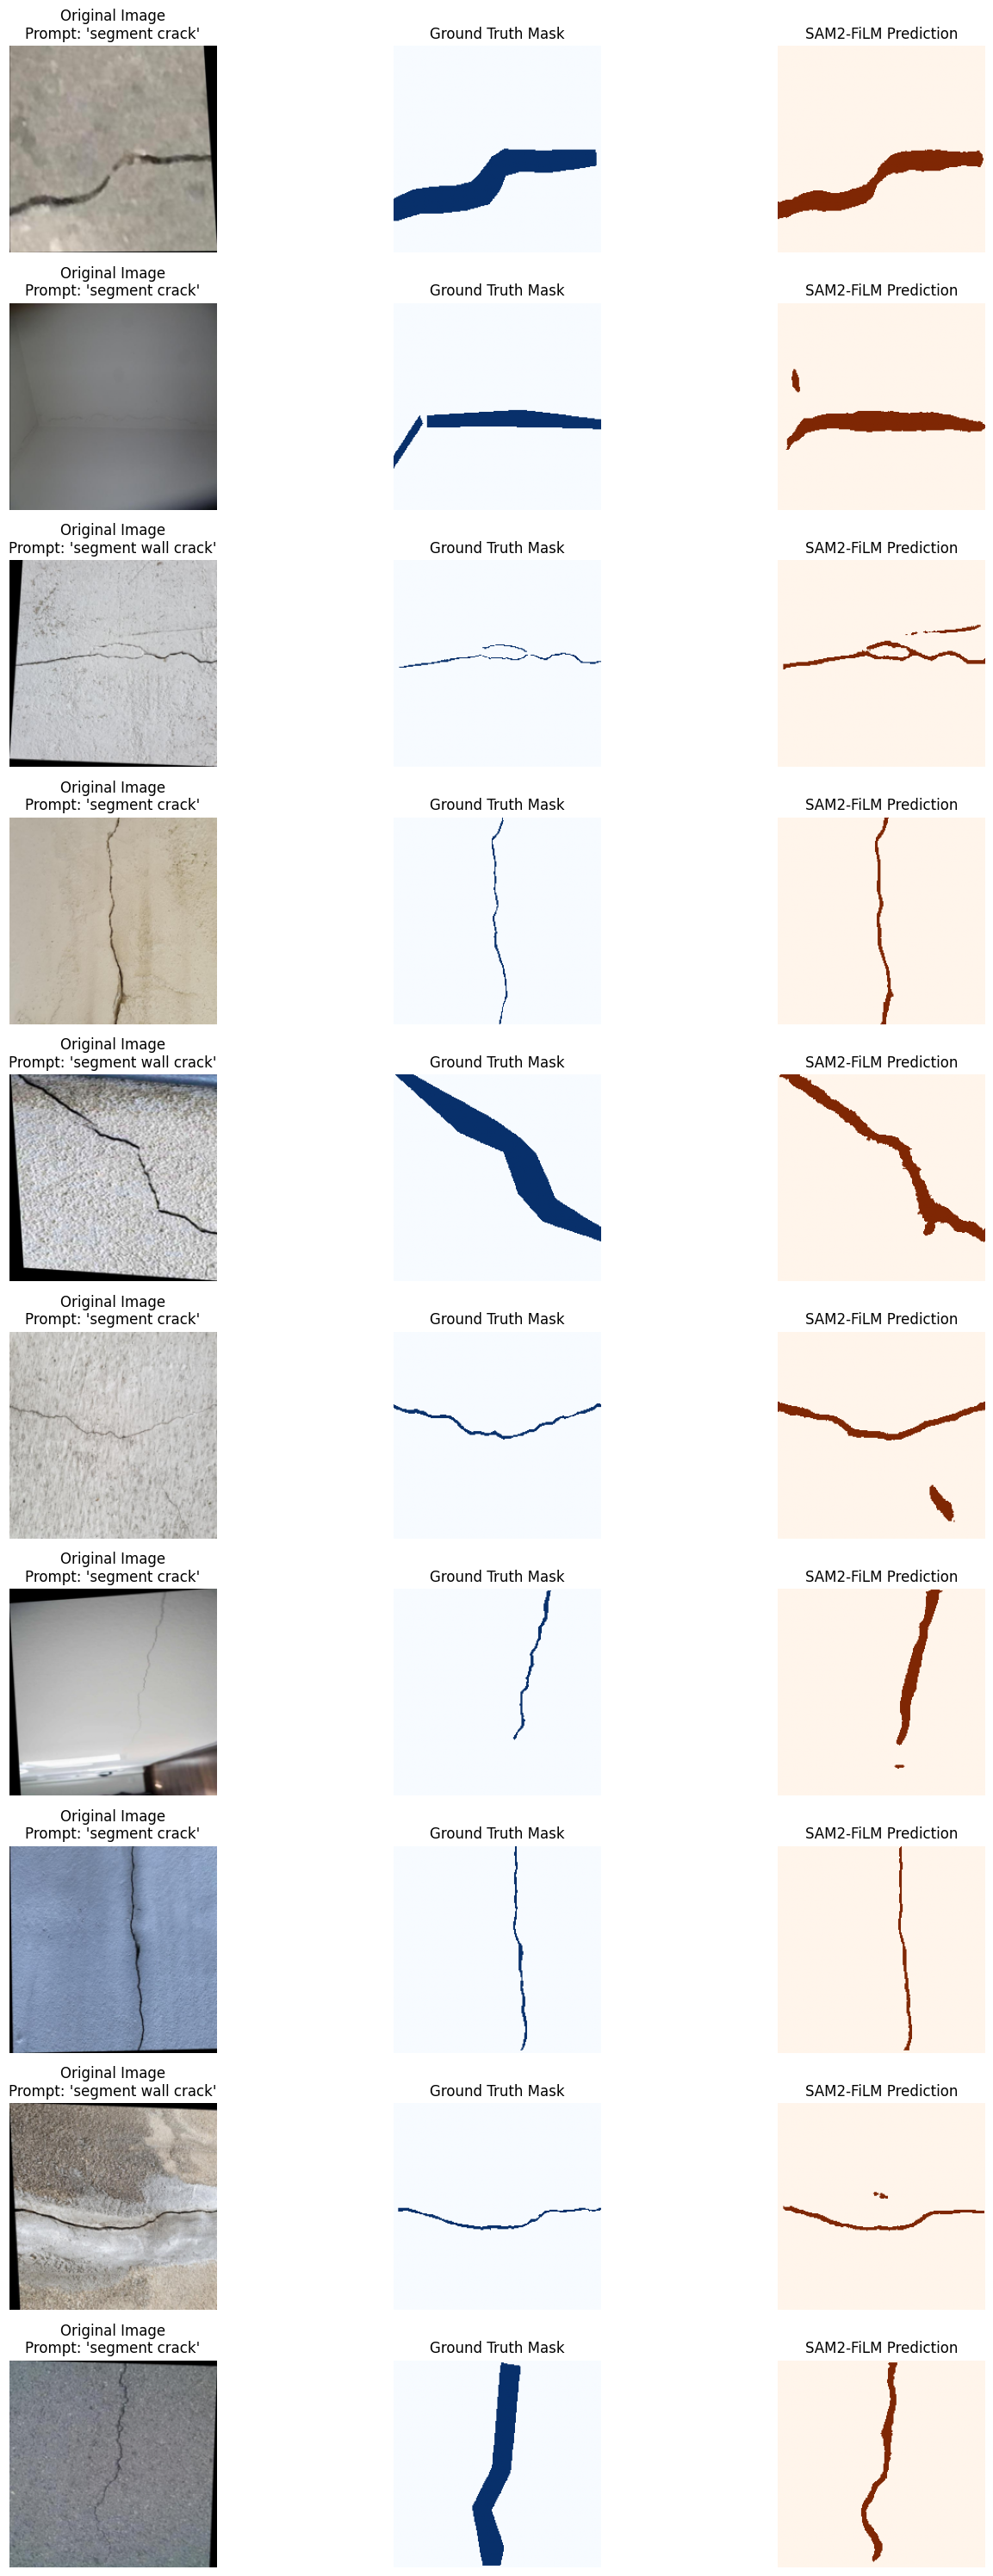

In [20]:
# 8. Visually Inspecting Model Predictions against Ground Truth
fig, axes = plt.subplots(10, 3, figsize=(15, 30))
examples_shown = 0

with torch.no_grad():
    for images, masks, prompts in test_loader:
        images_cuda = images.to(cfg.DEVICE)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        logits = model(images_cuda, text_emb)
        
        for i in range(len(images)):
            if examples_shown >= 10: break
            
            original = images[i].permute(1, 2, 0).numpy()
            axes[examples_shown, 0].imshow(original)
            axes[examples_shown, 0].set_title(f"Original Image\nPrompt: '{prompts[i]}'")
            axes[examples_shown, 0].axis("off")
            
            gt_mask = masks[i].squeeze().numpy()
            axes[examples_shown, 1].imshow(gt_mask, cmap="Blues")
            axes[examples_shown, 1].set_title("Ground Truth Mask")
            axes[examples_shown, 1].axis("off")
            
            pred_mask = (torch.sigmoid(logits[i]).cpu().squeeze().numpy() > 0.5).astype(np.float32)
            axes[examples_shown, 2].imshow(pred_mask, cmap="Oranges")
            axes[examples_shown, 2].set_title("SAM2-FiLM Prediction")
            axes[examples_shown, 2].axis("off")
            
            examples_shown += 1
            
        if examples_shown >= 10: break

plt.tight_layout()
plt.show()


Scanning Test Set for the absolute Worst Performing Images...


Finding Failure Cases: 100%|██████████████████| 202/202 [00:10<00:00, 19.01it/s]
/tmp/ipykernel_589380/2195074182.py:56: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


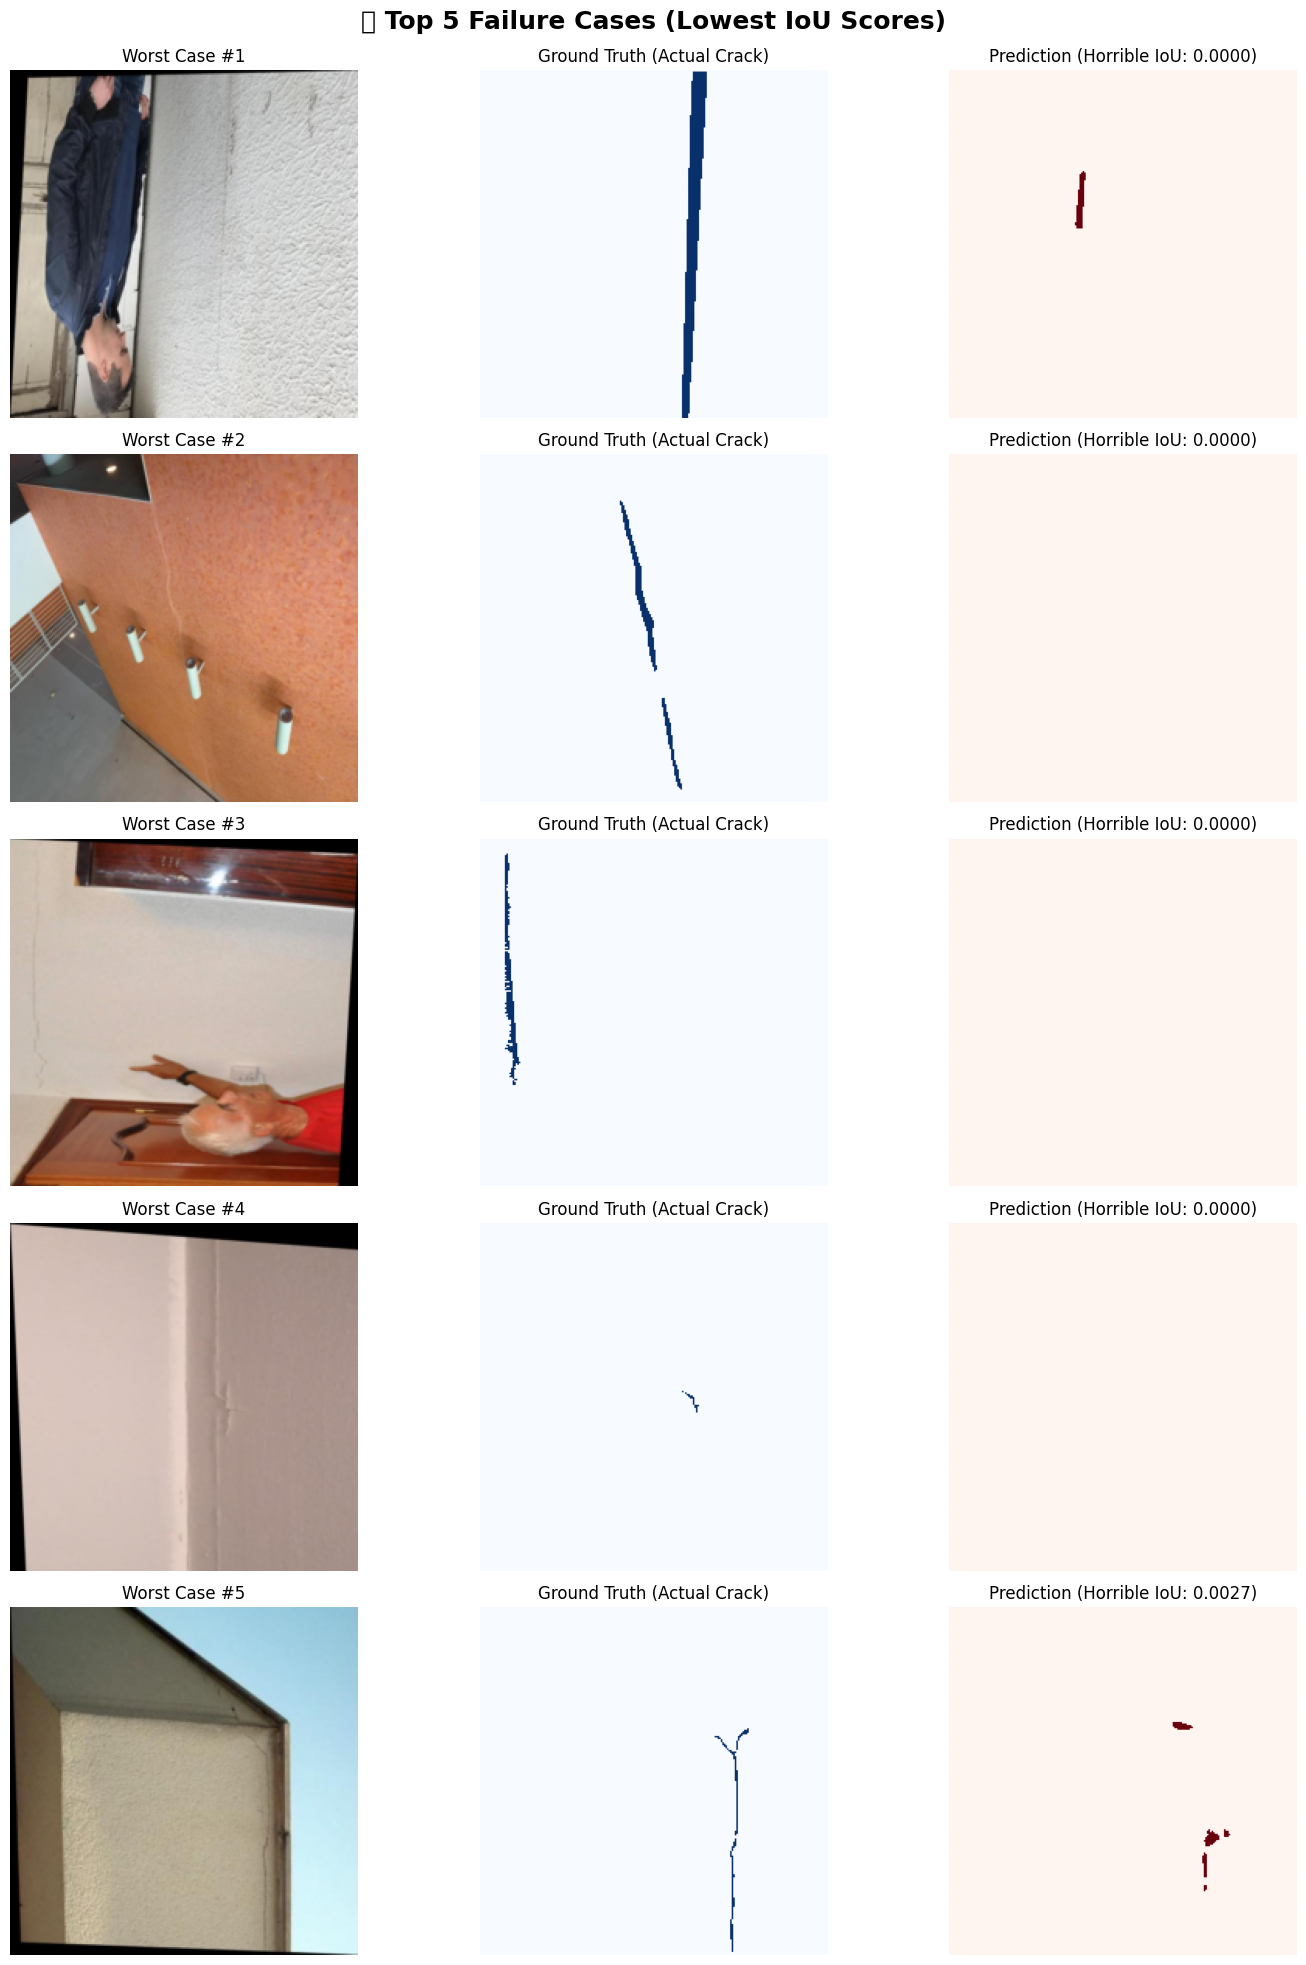

In [21]:
# ==============================================================================
# 9. FAILURE CASE ANALYSIS (Finding the Model's Blind Spots)
# ==============================================================================
print("Scanning Test Set for the absolute Worst Performing Images...")
model.eval()

failure_cases = [] # Stores: (IoU, Image, GroundTruth, Prediction)

with torch.no_grad():
    for images, masks, prompts in tqdm(test_loader, desc="Finding Failure Cases"):
        images_cuda = images.to(cfg.DEVICE, non_blocking=True)
        text_emb = torch.stack([text_cache[p][0] for p in prompts])
        
        logits = model(images_cuda, text_emb)
        preds_binary = (torch.sigmoid(logits) > 0.5).float()
        
        # Calculate individual Foreground IoU for *each* image separately
        for i in range(len(images)):
            p = preds_binary[i].flatten()
            t = masks[i].to(cfg.DEVICE).flatten()
            
            inter = (p * t).sum().item()
            union = p.sum().item() + t.sum().item() - inter
            iou = (inter + 1e-6) / (union + 1e-6)
            
            failure_cases.append((
                iou, 
                images[i].permute(1, 2, 0).numpy(),     # Original RGB
                masks[i].squeeze().numpy(),             # Ground Truth
                preds_binary[i].cpu().squeeze().numpy() # Model Prediction
            ))

# Sort the entire dataset exactly by IoU score (Lowest to Highest)
failure_cases.sort(key=lambda x: x[0])

# Grab the 5 absolute worst predictions
top_5_worst = failure_cases[:5]

# Plot the failures
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.suptitle("🚨 Top 5 Failure Cases (Lowest IoU Scores)", fontsize=18, fontweight='bold')

for i, (iou, img, gt, pred) in enumerate(top_5_worst):
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Worst Case #{i+1}")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gt, cmap="Blues")
    axes[i, 1].set_title(f"Ground Truth (Actual Crack)")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(pred, cmap="Reds")
    axes[i, 2].set_title(f"Prediction (Horrible IoU: {iou:.4f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


In [6]:
import time
import torch
try:
    from thop import profile
except ImportError:
    !pip install thop
    from thop import profile

model.eval()
dummy_img = torch.randn(1, 3, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE).to(cfg.DEVICE)
dummy_txt = torch.randn(1, 512).to(cfg.DEVICE)

# 1. Parameters & FLOPs
flops, params = profile(model, inputs=(dummy_img, dummy_txt), verbose=False)

# 2. Inference Time (Warmup then average)
with torch.no_grad():
    for _ in range(5): model(dummy_img, dummy_txt) # Warmup
    
    start = time.time()
    for _ in range(10):
        _ = model(dummy_img, dummy_txt)
    avg_inference_time = ((time.time() - start) / 10) * 1000 # in ms

print("=" * 40)
print(f"Parameters:     {params/1e6:.2f} M")
print(f"FLOPs:          {flops/1e9:.2f} G")
print(f"Inference Time: {avg_inference_time:.2f} ms")
print("=" * 40)

Parameters:     87.59 M
FLOPs:          17.99 G
Inference Time: 21.44 ms
